In [1147]:
import pandas as pd
import matplotlib.pyplot as plt
# import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [1148]:
df = pd.read_csv("./iris_shuffled.csv")
df.head()

,sepallength,sepalwidth,petallength,petalwidth,class
0,6.8,3.2,5.9,2.3,Iris-virginica
1,5.4,3.9,1.3,0.4,Iris-setosa
2,6.3,2.5,4.9,1.5,Iris-versicolor
3,5.6,2.5,3.9,1.1,Iris-versicolor
4,4.6,3.6,1.0,0.2,Iris-setosa


In [1149]:
# Data wrangling 
label_encoder = LabelEncoder()
temp_df = df.copy()

temp_df["class"] = label_encoder.fit_transform(df["class"]).astype('int64')

In [1150]:
temp_df.head()

,sepallength,sepalwidth,petallength,petalwidth,class
0,6.8,3.2,5.9,2.3,2
1,5.4,3.9,1.3,0.4,0
2,6.3,2.5,4.9,1.5,1
3,5.6,2.5,3.9,1.1,1
4,4.6,3.6,1.0,0.2,0


In [1151]:
temp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sepallength  150 non-null    float64
 1   sepalwidth   150 non-null    float64
 2   petallength  150 non-null    float64
 3   petalwidth   150 non-null    float64
 4   class        150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [1152]:
# class 0 = Iris-setosa
# class 1 = Iris-versicolor
# class 2 = Iris-virginica

## EDA

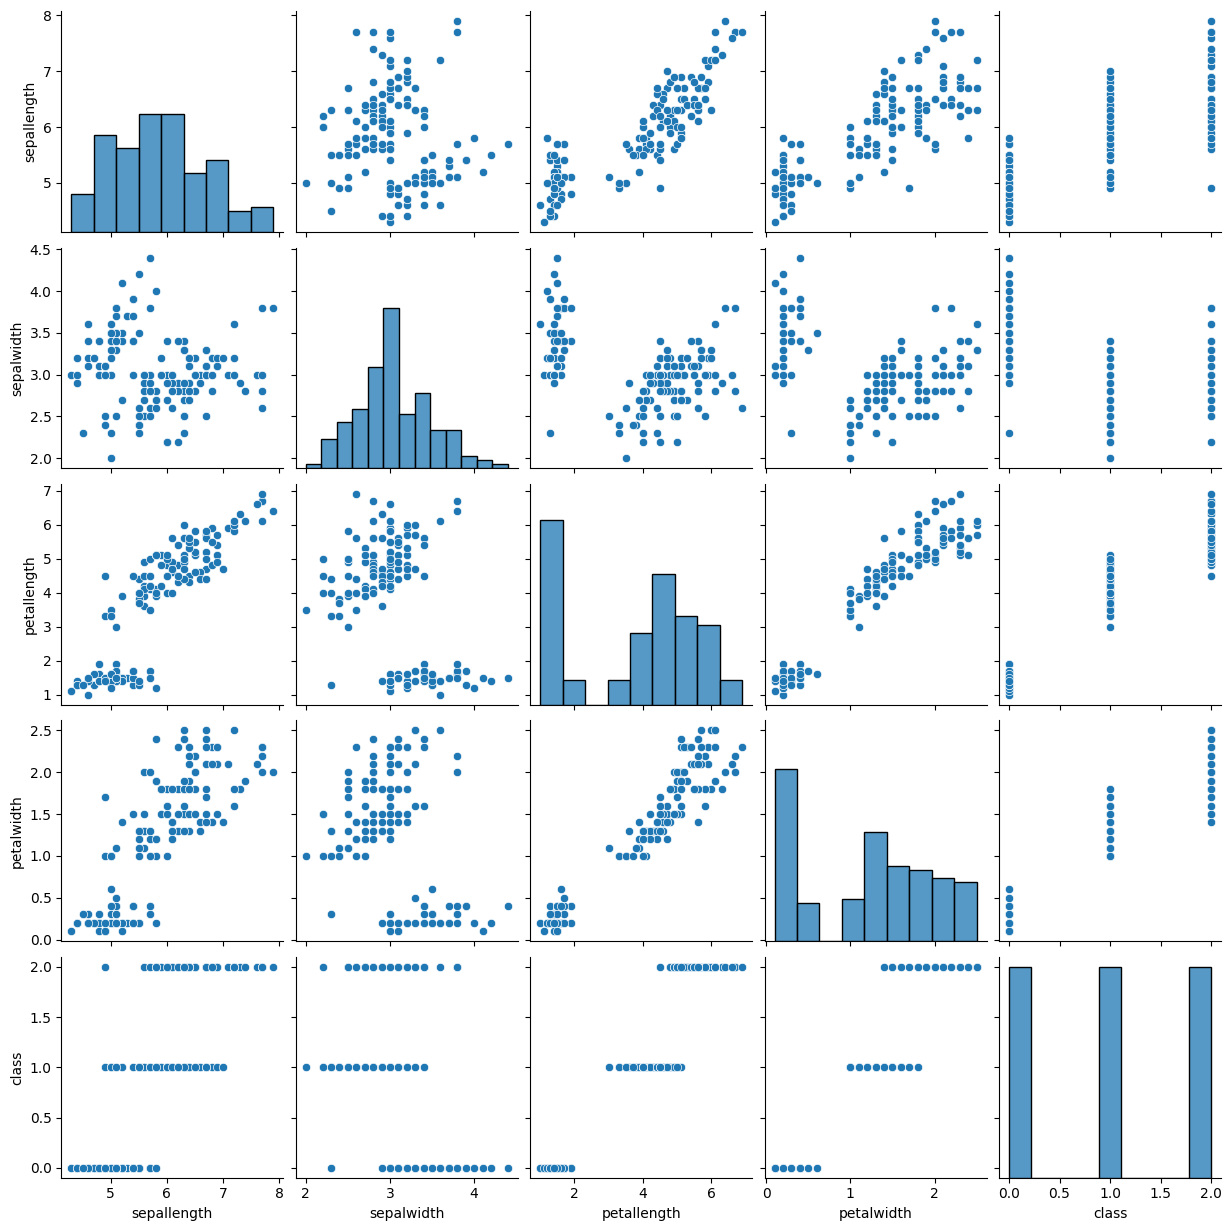

In [1153]:
sns.pairplot(temp_df)

plt.show()

### Checking Skewness in histogram

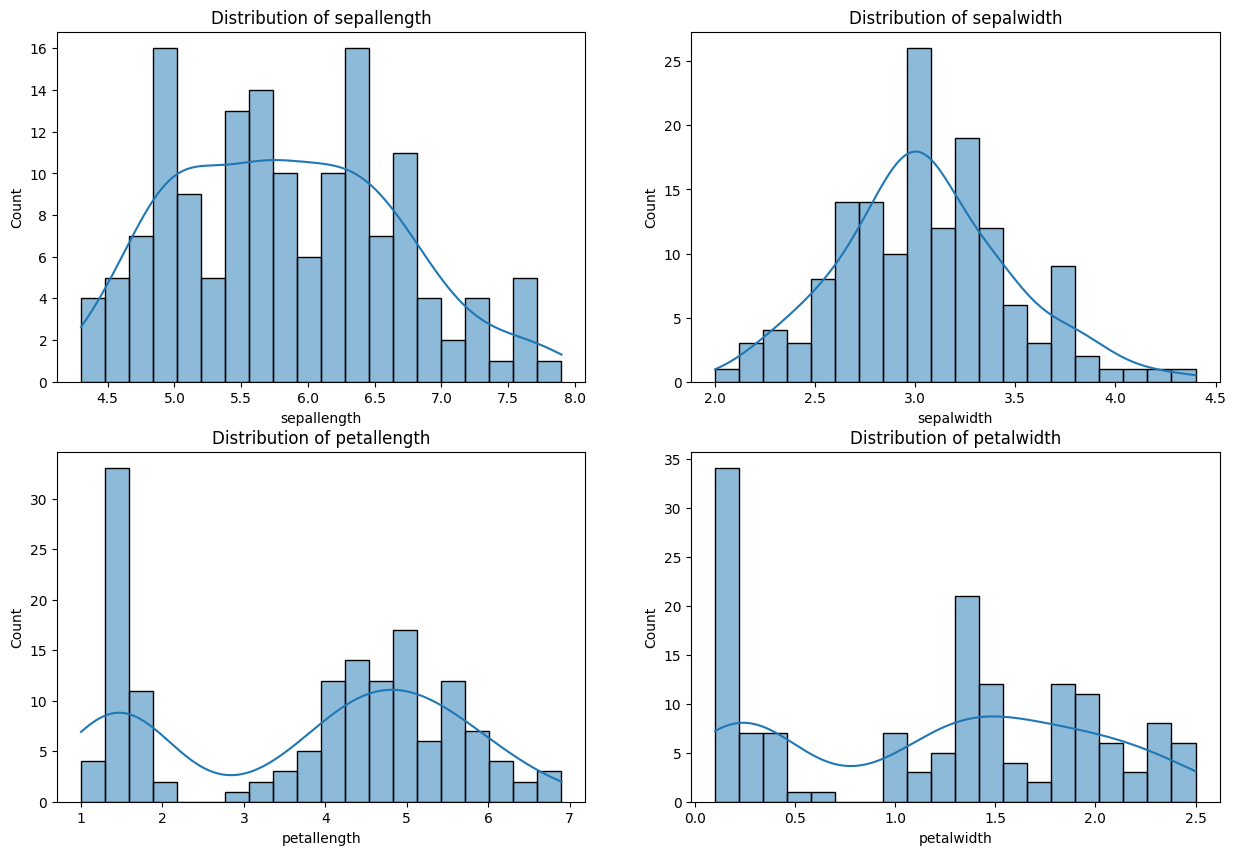

In [1154]:
fig = plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.histplot(data=temp_df["sepallength"],bins=20, kde=True)
plt.title("Distribution of sepallength")

plt.subplot(2, 2, 2)
sns.histplot(data=temp_df["sepalwidth"],bins=20, kde=True)
plt.title("Distribution of sepalwidth")

plt.subplot(2, 2, 3)
sns.histplot(data=temp_df["petallength"],bins=20, kde=True)
plt.title("Distribution of petallength")

plt.subplot(2, 2, 4)
sns.histplot(data=temp_df["petalwidth"],bins=20, kde=True)
plt.title("Distribution of petalwidth")

plt.show()

### Checking skewness in number

In [1155]:
for key, column in temp_df.items():
    if key=="class":
        continue
    print(f"{key}: Mean = {column.mean()} Standard Deviation = {column.std()} Skewness = {column.skew()}")

sepallength: Mean = 5.843333333333334 Standard Deviation = 0.8280661279778629 Skewness = 0.3149109566369727
sepalwidth: Mean = 3.0540000000000003 Standard Deviation = 0.4335943113621737 Skewness = 0.3340526621720866
petallength: Mean = 3.758666666666666 Standard Deviation = 1.7644204199522626 Skewness = -0.2744642524737828
petalwidth: Mean = 1.1986666666666668 Standard Deviation = 0.7631607417008411 Skewness = -0.10499656214412734


#### Skewness is between -0.5 to 0.5 so no transformation or correction is needed | Mean and SD aren't high enough for requiring normalization

### Checking for outliers

In [1156]:
temp_df

,sepallength,sepalwidth,petallength,petalwidth,class
0,6.8,3.2,5.9,2.3,2
1,5.4,3.9,1.3,0.4,0
2,6.3,2.5,4.9,1.5,1
3,5.6,2.5,3.9,1.1,1
4,4.6,3.6,1.0,0.2,0
...,...,...,...,...,...
145,6.3,2.5,5.0,1.9,2
146,5.1,3.4,1.5,0.2,0
147,7.7,2.6,6.9,2.3,2
148,5.8,2.7,5.1,1.9,2


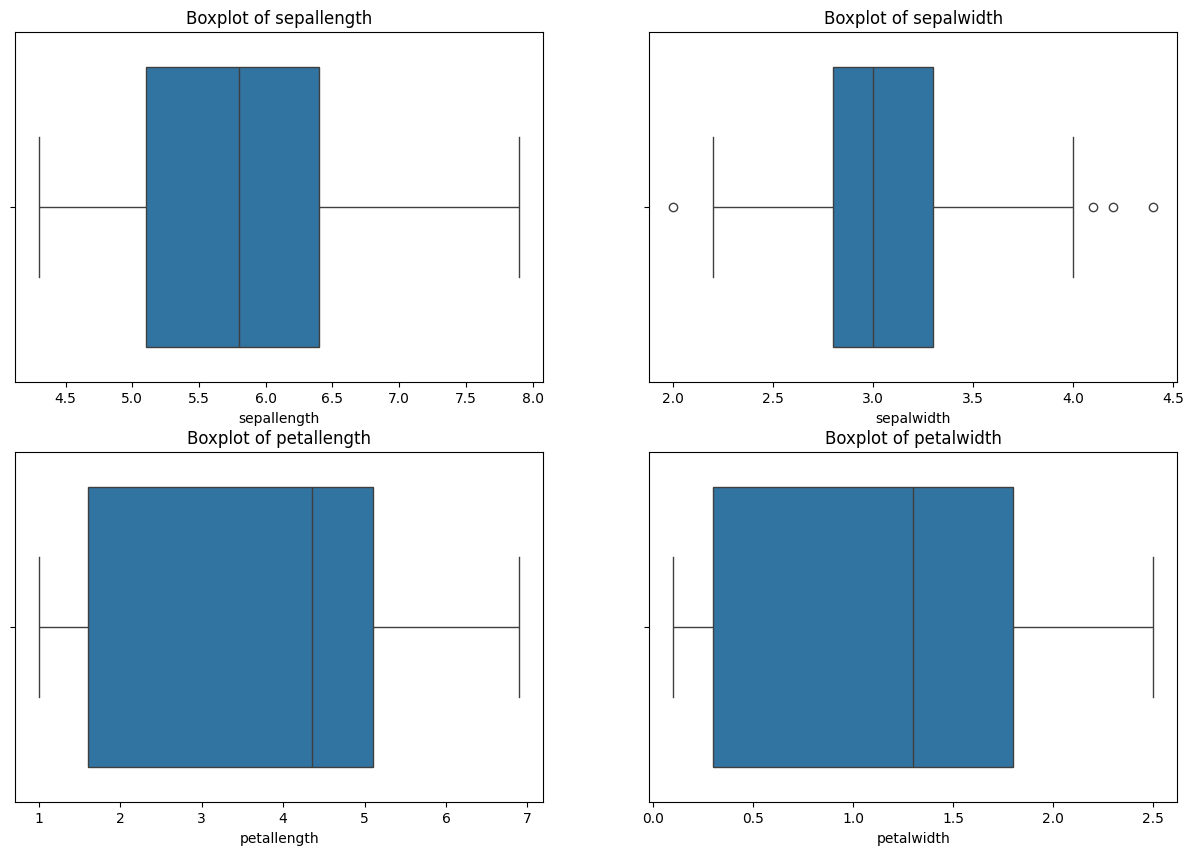

In [1157]:
fig = plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.boxplot(temp_df, x="sepallength")
plt.title("Boxplot of sepallength")

plt.subplot(2, 2, 2)
sns.boxplot(temp_df, x="sepalwidth")
plt.title("Boxplot of sepalwidth")

plt.subplot(2, 2, 3)
sns.boxplot(temp_df, x="petallength")
plt.title("Boxplot of petallength")

plt.subplot(2, 2, 4)
sns.boxplot(temp_df, x="petalwidth")
plt.title("Boxplot of petalwidth")

plt.show()

#### Outliers seen in sepalwidth which can mostly be neglected but we are handling the outlier for a good measure.

#### Outlier handling by IQR for small sample

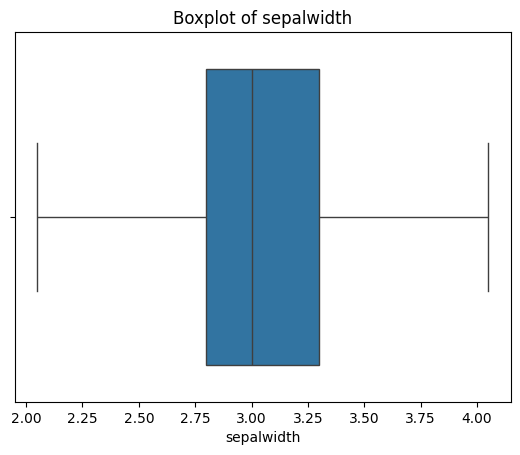

In [1158]:
q1_sw = temp_df["sepalwidth"].quantile(0.25)
q3_sw = temp_df["sepalwidth"].quantile(0.75)

iqr_sw = q3_sw - q1_sw # Interquartile range
lb_sw = q1_sw - 1.5 * iqr_sw # Lower bound
ub_sw = q3_sw + 1.5 * iqr_sw # Upper bound

for index, sw in temp_df["sepalwidth"].items():
    if sw < lb_sw:
        temp_df.at[index, "sepalwidth"] = lb_sw
    elif sw > ub_sw:
        temp_df.at[index, "sepalwidth"] = ub_sw
        
sns.boxplot(temp_df, x="sepalwidth")
plt.title("Boxplot of sepalwidth")
plt.show()

### Splitting the data

In [1159]:
from sklearn.model_selection import train_test_split

In [1160]:
y = temp_df["class"]
x = temp_df.drop("class", axis=1)

In [1161]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=67)

In [1162]:
# df_train = temp_df[: int(0.6 * len(temp_df))]
# df_val = temp_df[int(0.6 * len(temp_df)) : int(0.8 * len(temp_df))]
# df_test = temp_df[int(0.8 * len(temp_df)) : ]

# df_train.shape, df_val.shape, df_test.shape

In [1163]:
# y_train = df_train["class"].values
# x_train = df_train.drop("class", axis=1).values

# y_val = df_val["class"].values
# x_val = df_val.drop("class", axis=1).values

# y_test = df_test["class"].values
# x_test = df_test.drop("class", axis=1).values

In [1164]:
# y_train = y_train.reshape((y_train.shape[0], -1))
# y_val = y_val.reshape((y_val.shape[0], -1))
# y_test = y_test.reshape((y_test.shape[0], -1))

In [1165]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((120, 4), (120,), (30, 4), (30,))

### Training the data (Soft voting)

In [1166]:
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score

In [1167]:
# Initialize base learners
base_learners = [
    ('lr', LogisticRegression(multi_class='multinomial',random_state=42, n_jobs=-1, max_iter=5000, solver='saga')),
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=50, criterion='gini', max_depth=None, max_features='sqrt', min_samples_leaf=1,min_samples_split=2, n_jobs=-1)),
    ('knn', KNeighborsClassifier(metric='manhattan', n_neighbors=9, p=1, weights='distance')),
    ('svc', SVC(probability=True, C=100, kernel='poly'))
]


Best Parameters: {'metric': 'manhattan', 'n_neighbors': 9, 'p': 1, 'weights': 'distance'}

In [1168]:
# Create a voting classifier
voting_clf = VotingClassifier(estimators=base_learners, voting='soft')

# Train the voting classifier
voting_clf.fit(x_train, y_train)

C:\Users\kinga\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,estimators,"[('lr', ...), ('dt', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


In [1169]:
# Make predictions
predictions = voting_clf.predict(x_test)

# Evaluate model
accuracy = accuracy_score(y_test, predictions)
print(f'Accuracy: {accuracy}')

precision = precision_score(y_test, predictions, average='weighted')
print(f'Precision: {precision}')

recall = recall_score(y_test, predictions, average='weighted')
print(f'Recall: {recall}')

f1score = f1_score(y_test, predictions, average='weighted')
print(f'f1 score: {f1score}')

Accuracy: 0.9333333333333333
Precision: 0.9333333333333333
Recall: 0.9333333333333333
f1 score: 0.9333333333333333


### Results (Confusion Matrix)

In [1170]:
voting_clf.classes_

array([0, 1, 2])

In [1171]:
class_names = label_encoder.inverse_transform(voting_clf.classes_)
class_names

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

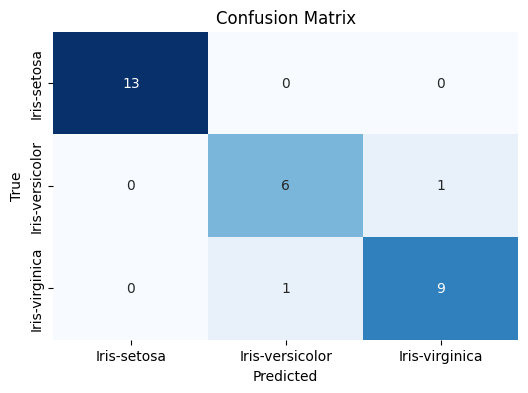

In [1172]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

### Individual results

In [1173]:
results = []

for name, model in base_learners:
    model.fit(x_train, y_train)
    individual_prediction = model.predict(x_test)
    
    acc = accuracy_score(y_test, individual_prediction)
    prec = precision_score(y_test, individual_prediction, average='weighted')
    rec = recall_score(y_test, individual_prediction, average='weighted')
    f1 = f1_score(y_test, individual_prediction, average='weighted')
    
    results.append((name, acc, prec, rec, f1))

results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])
results_df = results_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

print(results_df)

C:\Users\kinga\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Model  Accuracy  Precision    Recall  F1 Score
0    lr  0.966667   0.970833  0.966667  0.966901
1   svc  0.966667   0.969697  0.966667  0.966178
2    dt  0.933333   0.933333  0.933333  0.933333
3    rf  0.900000   0.900505  0.900000  0.898535
4   knn  0.900000   0.904630  0.900000  0.900702


Logistic Regression and SVC seems to give better results

### Extra: Hard voting

In [1174]:
# Create a voting classifier
voting_clf = VotingClassifier(estimators=base_learners, voting='hard')

# Train the voting classifier
voting_clf.fit(x_train, y_train)

# Make predictions
predictions = voting_clf.predict(x_test)

# Evaluate model
accuracy = accuracy_score(y_test, predictions)
print(f'Accuracy: {accuracy}')

precision = precision_score(y_test, predictions, average='weighted')
print(f'Precision: {precision}')

recall = recall_score(y_test, predictions, average='weighted')
print(f'Recall: {recall}')

f1score = f1_score(y_test, predictions, average='weighted')
print(f'f1 score: {f1score}')

C:\Users\kinga\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.9333333333333333
Precision: 0.9333333333333333
Recall: 0.9333333333333333
f1 score: 0.9333333333333333


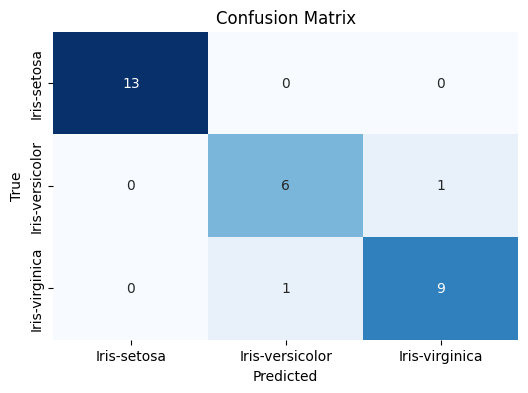

In [1175]:
class_names = label_encoder.inverse_transform(voting_clf.classes_)
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

The end results were slightly better with hard voting as Logistic regression and SVC were better models but two of the model i.e. KNN and RF had lower % in all evaluation metrics

With only LR and SVC used for voting, we can get all metrics to about 96%.